In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import cdsapi
import zipfile
import geopandas as gpd
import unicodedata

# Functions

In [36]:
def load_ibge_harvest(csv, feature_name):

    years_to_analize = [str(year) for year in range(2003, 2025)]
    cols = ['level', 'code', 'name'] + years_to_analize
    
    df_raw = pd.read_csv(csv, header=None, names=cols, sep=';', engine='python')
    
    df_mu = df_raw[df_raw['level'] == 'MU']

    df_mu = df_mu.replace('-', 0).replace('...', 0)

    df_mu_pv = pd.melt(
        df_mu,
        id_vars=['code', 'name'],
        value_vars=years_to_analize,
        var_name='year',
        value_name=feature_name
    )
    
    df_mu_pv['year'] = df_mu_pv['year'].astype(int)
    df_mu_pv[feature_name] = df_mu_pv[feature_name].astype(int)
    
    return df_mu_pv

In [67]:
def process_era5_data(input_folder, output_csv='master_era5_yearly_summary.csv'):
    zip_files = glob.glob(os.path.join(input_folder, "ERA5_*.zip"))
        
    all_municipalities_data = []
    
    def max_consecutive_dry_days(series):
        is_dry = series == 0
        return is_dry.groupby((~is_dry).cumsum()).sum().max()

    for zip_path in zip_files:
        filename = os.path.basename(zip_path)
        city_name = filename.replace('ERA5_', '').replace('.zip', '').replace('_', ' ')
        
        print(f"Processing: {city_name}...")
        

        with zipfile.ZipFile(zip_path, 'r') as z:
            csv_names = [n for n in z.namelist() if n.endswith('.csv')]
            with z.open(csv_names[0]) as f:
                df_raw = pd.read_csv(f)
        
        df_raw['valid_time'] = pd.to_datetime(df_raw['valid_time'])
        df_raw.set_index('valid_time', inplace=True)
        
        df_filled = pd.DataFrame(index=df_raw.index)
        
        df_filled['air_temperature_c'] = df_raw['t2m'] - 273.15
        
        df_filled['precipitation_mm'] = df_raw['tp'] * 1000
        
        df_filled['global_radiation_kj_m2'] = df_raw['ssrd'] / 1000
        
        t_c = df_filled['air_temperature_c']
        td_c = df_raw['d2m'] - 273.15
        actual_vapor_press = np.exp((17.625 * td_c) / (243.04 + td_c))
        sat_vapor_press = np.exp((17.625 * t_c) / (243.04 + t_c))
        df_filled['relative_humidity_pct'] = 100 * (actual_vapor_press / sat_vapor_press)
        df_filled['relative_humidity_pct'] = df_filled['relative_humidity_pct'].clip(lower=0, upper=100)

        # Filter for the critical Corn window in Mato Grosso (January to September)
        df_filtered = df_filled[(df_filled.index.month >= 1) & (df_filled.index.month <= 9)].copy()
        df_filtered['hourly_heat_stress'] = df_filtered['air_temperature_c'] >= 35

        daily_df = df_filtered.groupby(df_filtered.index.date).agg(
            daily_precipitation=('precipitation_mm', 'sum'),
            daily_t_mean=('air_temperature_c', 'mean'),  
            daily_t_max=('air_temperature_c', 'max'),     
            daily_t_min=('air_temperature_c', 'min'),
            total_heat_hours=('hourly_heat_stress', 'sum'),
            daily_rad_kj=('global_radiation_kj_m2', 'sum'),
            daily_rh_mean=('relative_humidity_pct', 'mean'),
            daily_rh_min=('relative_humidity_pct', 'min')
        )

        daily_df.index = pd.to_datetime(daily_df.index)
        daily_df['year'] = daily_df.index.year

        daily_df['thermal_amplitude'] = daily_df['daily_t_max'] - daily_df['daily_t_min']

        t_max_capped = daily_df['daily_t_max'].clip(upper=30, lower=10)
        t_min_floored = daily_df['daily_t_min'].clip(upper=30, lower=10)
        daily_df['gdd'] = np.maximum(((t_max_capped + t_min_floored) / 2) - 10, 0)

        daily_df['is_temp_24_to_30'] = daily_df['daily_t_mean'].between(24, 30)
        daily_df['is_temp_ge_35'] = daily_df['daily_t_max'] >= 35
        daily_df['is_temp_lt_24'] = daily_df['daily_t_mean'] < 24
        daily_df['is_tropical_night'] = daily_df['daily_t_min'] >= 22

        daily_df['is_rainy_day'] = daily_df['daily_precipitation'] > 0
        daily_df['is_heavy_rain'] = daily_df['daily_precipitation'] >= 20
        daily_df['is_ineffective_rain'] = daily_df['daily_precipitation'].between(0.1, 2.0, inclusive='neither')

        daily_df['daily_rad_mj'] = daily_df['daily_rad_kj'] / 1000
        daily_df['is_critical_low_rh'] = daily_df['daily_rh_min'] <= 30
        daily_df['is_high_rh_stress'] = daily_df['daily_rh_mean'] >= 80

        master_yearly_summary = daily_df.groupby('year').agg(
            mean_temperature_c=('daily_t_mean', 'mean'),  
            max_temperature_c=('daily_t_max', 'max'),    
            min_temperature_c=('daily_t_min', 'min'),    
            total_gdd_accumulated=('gdd', 'sum'),                    
            avg_thermal_amplitude=('thermal_amplitude', 'mean'),       
            days_with_tropical_nights=('is_tropical_night', 'sum'),    
            total_hours_above_35=('total_heat_hours', 'sum'),          
            days_temp_24_to_30=('is_temp_24_to_30', 'sum'),
            days_temp_ge_35=('is_temp_ge_35', 'sum'),
            days_temp_lt_24=('is_temp_lt_24', 'sum'),
            
            total_rain_mm=('daily_precipitation', 'sum'),
            days_with_rain=('is_rainy_day', 'sum'),
            heavy_rain_days=('is_heavy_rain', 'sum'),
            ineffective_rain_days=('is_ineffective_rain', 'sum'),
            max_consecutive_dry_days=('daily_precipitation', max_consecutive_dry_days),
            
            total_radiation_mj_m2=('daily_rad_mj', 'sum'),
            avg_daily_radiation_mj_m2=('daily_rad_mj', 'mean'),
            mean_relative_humidity_pct=('daily_rh_mean', 'mean'),
            days_critical_low_rh=('is_critical_low_rh', 'sum'),
            days_high_rh_stress=('is_high_rh_stress', 'sum')
        ).reset_index()

        master_yearly_summary['rain_intensity_mm_per_day'] = (
            master_yearly_summary['total_rain_mm'] / master_yearly_summary['days_with_rain']
        )

        master_yearly_summary = master_yearly_summary.round({
            'mean_temperature_c': 1, 'max_temperature_c': 1, 'min_temperature_c': 1,
            'total_gdd_accumulated': 0, 'avg_thermal_amplitude': 1,
            'total_rain_mm': 1, 'rain_intensity_mm_per_day': 1,
            'total_radiation_mj_m2': 1, 'avg_daily_radiation_mj_m2': 1,
            'mean_relative_humidity_pct': 1
        })
        
        master_yearly_summary['municipality'] = city_name
        all_municipalities_data.append(master_yearly_summary)
        
    final_panel_df = pd.concat(all_municipalities_data, ignore_index=True)

    cols = ['municipality', 'year'] + [c for c in final_panel_df.columns if c not in ['municipality', 'year']]
    final_panel_df = final_panel_df[cols]

    return final_panel_df

# IBGE Dataset - Combining the information of Yeld area and Production by hectare

In [138]:
df_area = load_ibge_harvest('area_plantada.csv', 'planted_area_ha')
df_yield = load_ibge_harvest('kg_por_hectare.csv', 'yield_kg_ha')

In [139]:
df_yield.drop(columns=['name'], inplace=True)

df_ibge_combined = pd.merge(
    df_area,
    df_yield,
    on=['code', 'year'],
    how='inner'
)

df_ibge_combined

df_ibge_combined = df_ibge_combined.loc[:, ~df_ibge_combined.columns.str.endswith('_duplicado')]

df_ibge_combined


,code,name,year,planted_area_ha,yield_kg_ha
0,5101407,Aripuanã,2003,0,0
1,5101902,Brasnorte,2003,7000,3600
2,5102850,Castanheira,2003,0,0
3,5103254,Colniza,2003,0,0
4,5103379,Cotriguaçu,2003,0,0
...,...,...,...,...,...
3097,5107297,São José do Povo,2024,0,0
3098,5107404,São Pedro da Cipa,2024,1400,5400
3099,5100300,Alto Araguaia,2024,15000,6600
3100,5100409,Alto Garças,2024,60000,6900


# ERA5 Dataset - Dowloading and grouping characteristics by year and municipality

In [50]:
municipies_yeld = df_ibge_combined[['code', 'name']].drop_duplicates()
ibge_coords = pd.read_csv('municipies.csv', sep=',')

municipies_coord = pd.merge(
    municipies_yeld,
    ibge_coords[['codigo_ibge', 'latitude', 'longitude']],
    left_on='code',
    right_on='codigo_ibge',
    how='left'
)

In [53]:
municipies_coord['lat_era5'] = np.round(municipies_coord['latitude'] * 4) / 4
municipies_coord['lon_era5'] = np.round(municipies_coord['longitude'] * 4) / 4

client = cdsapi.Client()
dataset = "reanalysis-era5-single-levels-timeseries"
os.makedirs('era5_downloads', exist_ok=True)

for index, row in municipies_coord.iterrows():
    # Clean name for the file system
    safe_name = str(row['name']).replace(" ", "_").replace("/", "-")
    target_file = f'era5_downloads/ERA5_{safe_name}.zip'
    
    # Skip if we already have it
    if os.path.exists(target_file):
        continue
        
    print(f"[{index+1}/{len(municipies_coord)}] Downloading: {row['name']}")
    
    request = {
        "variable": [
            "2m_temperature",
            "2m_dewpoint_temperature",
            "total_precipitation",
            "surface_solar_radiation_downwards",
            "total_sky_direct_solar_radiation_at_surface",
            "skin_temperature",                            
            "total_cloud_cover"                            
        ],
        "location": {
            "longitude": float(row['lon_era5']), 
            "latitude": float(row['lat_era5'])
        },
        "date": ["2003-01-01/2024-12-31"],
        "data_format": "csv"
    }

    # client.retrieve(dataset, request).download(target_file)

[1/141] Downloading:       Aripuanã
[2/141] Downloading:       Brasnorte
[3/141] Downloading:       Castanheira
[4/141] Downloading:       Colniza
[5/141] Downloading:       Cotriguaçu
[6/141] Downloading:       Juína
[7/141] Downloading:       Juruena
[8/141] Downloading:       Rondolândia
[9/141] Downloading:       Alta Floresta
[10/141] Downloading:       Apiacás
[11/141] Downloading:       Carlinda
[12/141] Downloading:       Nova Bandeirantes
[13/141] Downloading:       Nova Monte Verde
[14/141] Downloading:       Paranaíta
[15/141] Downloading:       Colíder
[16/141] Downloading:       Guarantã do Norte
[17/141] Downloading:       Matupá
[18/141] Downloading:       Nova Canaã do Norte
[19/141] Downloading:       Nova Guarita
[20/141] Downloading:       Novo Mundo
[21/141] Downloading:       Peixoto de Azevedo
[22/141] Downloading:       Terra Nova do Norte
[23/141] Downloading:       Campo Novo do Parecis
[24/141] Downloading:       Campos de Júlio
[25/141] Downloading:       Com

In [68]:
df_final_era5 = process_era5_data(input_folder='./era5_downloads')

Processing: Alto Araguaia...
Processing: Alto Garças...
Processing: Alto Taquari...
Processing: Brasnorte...
Processing: Campos de Júlio...
Processing: Campo Novo do Parecis...
Processing: Campo Verde...
Processing: Chapada dos Guimarães...
Processing: Cláudia...
Processing: Comodoro...
Processing: Diamantino...
Processing: Dom Aquino...
Processing: Guiratinga...
Processing: Itaúba...
Processing: Itiquira...
Processing: Jaciara...
Processing: Juscimeira...
Processing: Lucas do Rio Verde...
Processing: Matupá...
Processing: Nobres...
Processing: Nortelândia...
Processing: Nova Marilândia...
Processing: Nova Maringá...
Processing: Nova Mutum...
Processing: Nova Ubiratã...
Processing: Novo Mundo...
Processing: Novo São Joaquim...
Processing: Paranatinga...
Processing: Pedra Preta...
Processing: Peixoto de Azevedo...
Processing: Poxoréu...
Processing: Santa Carmem...
Processing: Santa Rita do Trivelato...
Processing: Santo Antônio do Leste...
Processing: Sapezal...
Processing: Sorriso...
P

In [69]:
df_final_era5

,municipality,year,mean_temperature_c,max_temperature_c,min_temperature_c,total_gdd_accumulated,avg_thermal_amplitude,days_with_tropical_nights,total_hours_above_35,days_temp_24_to_30,...,days_with_rain,heavy_rain_days,ineffective_rain_days,max_consecutive_dry_days,total_radiation_mj_m2,avg_daily_radiation_mj_m2,mean_relative_humidity_pct,days_critical_low_rh,days_high_rh_stress,rain_intensity_mm_per_day
0,Alto Araguaia,2003,22.9,36.1,10.5,3619.0,10.8,2,9,74,...,163,7,52,34,4925.8,18.0,68.7,23,92,5.7
1,Alto Araguaia,2004,23.2,36.4,11.4,3704.0,10.7,2,53,106,...,174,6,58,39,4966.1,18.1,69.3,42,102,4.3
2,Alto Araguaia,2005,23.5,34.8,11.0,3753.0,10.8,7,0,112,...,165,8,53,22,5002.2,18.3,68.1,29,79,4.6
3,Alto Araguaia,2006,23.1,34.0,10.8,3684.0,10.8,3,0,87,...,153,7,46,45,5005.6,18.3,68.9,12,93,5.9
4,Alto Araguaia,2007,23.6,36.6,9.2,3766.0,11.3,15,8,125,...,145,7,47,43,5090.1,18.6,65.5,39,72,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
941,Vera,2020,25.7,39.5,13.4,4164.0,11.4,105,239,249,...,153,7,56,77,5166.8,18.9,69.9,74,113,5.1
942,Vera,2021,25.3,37.3,12.5,4128.0,11.1,57,162,228,...,162,3,51,64,5150.5,18.9,72.5,42,112,5.7
943,Vera,2022,25.9,38.5,11.3,4161.0,11.6,75,204,239,...,157,9,50,29,5241.7,19.2,66.3,91,99,5.0
944,Vera,2023,25.9,38.3,12.8,4167.0,11.2,74,210,233,...,172,5,59,21,5158.1,18.9,69.8,67,97,5.4


# Calculating the aptitude % of the municipalities

In [72]:
aptitude = gpd.read_file("./Pedologia_shape/Classe_aptidao_agricola.shp")
municipies_shp = gpd.read_file("./MT_Municipios_2025/MT_Municipios_2025.shp")

In [87]:
import geopandas as gpd
import pandas as pd

municipies_shp = municipies_shp.to_crs(aptitude.crs)

municipies_shp['mun_total_area'] = municipies_shp.geometry.area

intersection = gpd.overlay(municipies_shp, aptitude, how='intersection')

intersection['intersect_area'] = intersection.geometry.area

intersection['percentage'] = (intersection['intersect_area'] / intersection['mun_total_area']) * 100

posology = intersection.pivot_table(
    index=['CD_MUN', 'NM_MUN'],  
    columns='descricao_',         
    values='percentage', 
    aggfunc='sum'
).fillna(0).round(2).reset_index()                    

posology.head()

descricao_,CD_MUN,NM_MUN,Aptidao Para Pastagem,Aptidao Para Silvicultura,Terra Com Aptidao Boa,Terra Com Aptidao Regular,Terra Com Aptidao Restrita,Terras Sem Aptidao
0,5100102,Acorizal,3.59,41.30,33.05,2.66,0.00,18.82
1,5100201,Água Boa,22.60,9.62,33.74,32.06,0.09,1.85
2,5100250,Alta Floresta,15.42,1.85,48.09,31.68,0.00,2.46
3,5100300,Alto Araguaia,38.15,3.22,6.13,30.37,0.00,21.95
4,5100359,Alto Boa Vista,5.95,0.42,10.77,82.84,0.00,0.00


# Combining the three datasets 

In [145]:


def normalizar_nome_cidade(nome):
    if pd.isna(nome):
        return ""
    nome_limpo = str(nome).strip().lower()
    nome_limpo = nome_limpo.replace('_', ' ').replace('-', ' ')
    nome_limpo = ''.join(
        c for c in unicodedata.normalize('NFD', nome_limpo)
        if unicodedata.category(c) != 'Mn'
    )
    return " ".join(nome_limpo.split())

df_ibge = df_ibge_combined.copy()
df_era5 = df_final_era5.copy()
df_poso = posology.copy()

df_ibge['chave_cidade'] = df_ibge['name'].apply(normalizar_nome_cidade)
df_era5['chave_cidade'] = df_era5['municipality'].apply(normalizar_nome_cidade)

df_ibge_era5 = pd.merge(
    df_ibge,
    df_era5,
    on=['chave_cidade', 'year'],
    how='inner'
)

df_poso['CD_MUN'] = df_poso['CD_MUN'].astype(int)

df_final = pd.merge(
    df_ibge_era5,
    df_poso,
    left_on='code',
    right_on='CD_MUN',
    how='inner'
)
df_final

df_final = df_final.drop(columns=['chave_cidade', 'code', 'name', 'municipality', 'CD_MUN', 'NM_MUN'])
df_final

,year,planted_area_ha,yield_kg_ha,mean_temperature_c,max_temperature_c,min_temperature_c,total_gdd_accumulated,avg_thermal_amplitude,days_with_tropical_nights,total_hours_above_35,...,mean_relative_humidity_pct,days_critical_low_rh,days_high_rh_stress,rain_intensity_mm_per_day,Aptidao Para Pastagem,Aptidao Para Silvicultura,Terra Com Aptidao Boa,Terra Com Aptidao Regular,Terra Com Aptidao Restrita,Terras Sem Aptidao
0,2003,7000,3600,25.0,36.0,15.2,4141.0,9.9,76,11,...,77.3,10,145,5.8,28.06,0.11,24.80,46.35,0.00,0.63
1,2003,1000,3000,25.6,36.0,17.3,4239.0,9.8,112,20,...,75.5,30,145,5.9,15.58,15.03,10.47,40.29,15.29,2.07
2,2003,1500,2820,25.6,35.9,17.4,4221.0,9.7,96,21,...,75.0,29,143,5.9,15.19,0.25,12.41,60.29,0.00,10.34
3,2003,500,2400,25.6,36.0,17.3,4239.0,9.8,112,20,...,75.5,30,145,5.9,18.17,1.96,6.56,22.48,42.66,7.13
4,2003,35000,3600,23.6,34.2,11.4,3857.0,9.2,14,0,...,74.2,4,126,4.6,20.58,0.00,58.24,21.18,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
941,2024,15000,6300,25.5,38.8,9.7,4096.0,11.0,133,202,...,64.3,83,68,6.6,29.96,25.18,12.08,22.24,0.00,10.46
942,2024,40000,6900,26.4,40.4,11.3,4211.0,11.7,138,279,...,63.3,85,50,5.0,21.84,18.36,32.66,1.45,0.00,25.70
943,2024,15000,6600,23.8,38.4,7.5,3765.0,12.3,11,107,...,63.9,99,82,5.3,38.15,3.22,6.13,30.37,0.00,21.95
944,2024,60000,6900,23.8,37.7,7.9,3769.0,11.9,7,82,...,64.1,98,87,6.1,63.66,7.82,16.34,9.84,0.95,1.39


# Model Applying

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = df_final.copy()

target = 'yield_kg_ha'

features = [col for col in df.columns if col not in [target, 'year', 'planted_area_ha']]

dados_treino = df[(df['year'] >= 2003) & (df['year'] <= 2020)]
X_train = dados_treino[features]
y_train = dados_treino[target]

dados_teste = df[(df['year'] >= 2021) & (df['year'] <= 2024)]
X_test = dados_teste[features]
y_test = dados_teste[target]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


modelo_tree = DecisionTreeRegressor(max_depth=5)
modelo_tree.fit(X_train_scaled, y_train)


predicoes = modelo_tree.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predicoes)
rmse = np.sqrt(mean_squared_error(y_test, predicoes))
r2 = r2_score(y_test, predicoes)

print(f"MAE: {mae:.2f} kg/ha")
print(f"RMSE: {rmse:.2f} kg/ha")
print(f"R²: {r2:.4f}")

=== Resultados da Árvore de Decisão (Teste: 2021-2024) ===
MAE: 1363.23 kg/ha
RMSE: 1731.14 kg/ha
R²: -4.4892


=== Feature Importance (Decision Tree) ===
                       Feature  Importance
0        total_radiation_mj_m2    0.252528
1               days_with_rain    0.120510
2        ineffective_rain_days    0.110589
3            max_temperature_c    0.104157
4    days_with_tropical_nights    0.100269
5            min_temperature_c    0.086115
6        total_gdd_accumulated    0.061327
7          days_high_rh_stress    0.058550
8         days_critical_low_rh    0.037518
9    avg_daily_radiation_mj_m2    0.028332
10             heavy_rain_days    0.015821
11   rain_intensity_mm_per_day    0.011857
12  mean_relative_humidity_pct    0.008755
13       avg_thermal_amplitude    0.002493
14    max_consecutive_dry_days    0.000874
15          Terras Sem Aptidao    0.000305


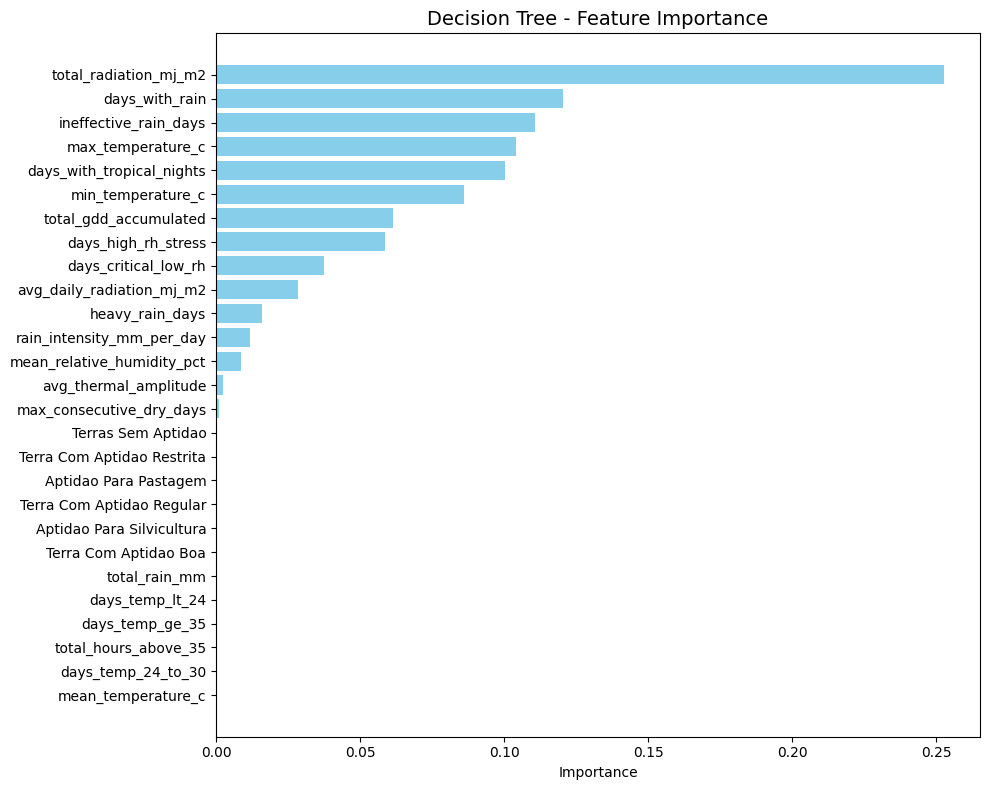

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

importances = modelo_tree.feature_importances_

indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in indices]
sorted_importances = importances[indices]

importance_df = pd.DataFrame({
    'Feature': sorted_features,
    'Importance': sorted_importances
})

plt.figure(figsize=(10, 8))
plt.title("Decision Tree - Feature Importance", fontsize=14)

plt.barh(range(len(features)), sorted_importances[::-1], align="center", color='skyblue')
plt.yticks(range(len(features)), sorted_features[::-1])
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig('dt_importance.pdf')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = df_final.copy()

target = 'yield_kg_ha'

features = [col for col in df.columns if col not in [target, 'year', 'planted_area_ha']]

dados_treino = df[(df['year'] >= 2003) & (df['year'] <= 2020)]
X_train = dados_treino[features]
y_train = dados_treino[target]

dados_teste = df[(df['year'] >= 2021) & (df['year'] <= 2024)]
X_test = dados_teste[features]
y_test = dados_teste[target]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

modelo_rf.fit(X_train_scaled, y_train)

predicoes = modelo_rf.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predicoes)
rmse = np.sqrt(mean_squared_error(y_test, predicoes))
r2 = r2_score(y_test, predicoes)

print(f"MAE (Erro Médio Absoluto): {mae:.2f} kg/ha")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f} kg/ha")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")

=== Resultados do Modelo (Teste: 2021-2024) ===
MAE (Erro Médio Absoluto): 1091.84 kg/ha
RMSE (Raiz do Erro Quadrático Médio): 1286.46 kg/ha
R² (Coeficiente de Determinação): -2.0314


=== Random Forest: Top 10 Feature Importances ===
                     Feature  Importance_Score
0      total_radiation_mj_m2          0.146744
1             days_with_rain          0.087778
2          min_temperature_c          0.085207
3      ineffective_rain_days          0.081552
4          max_temperature_c          0.063841
5        days_high_rh_stress          0.056106
6  days_with_tropical_nights          0.050536
7   max_consecutive_dry_days          0.049906
8      avg_thermal_amplitude          0.038643
9       total_hours_above_35          0.036603


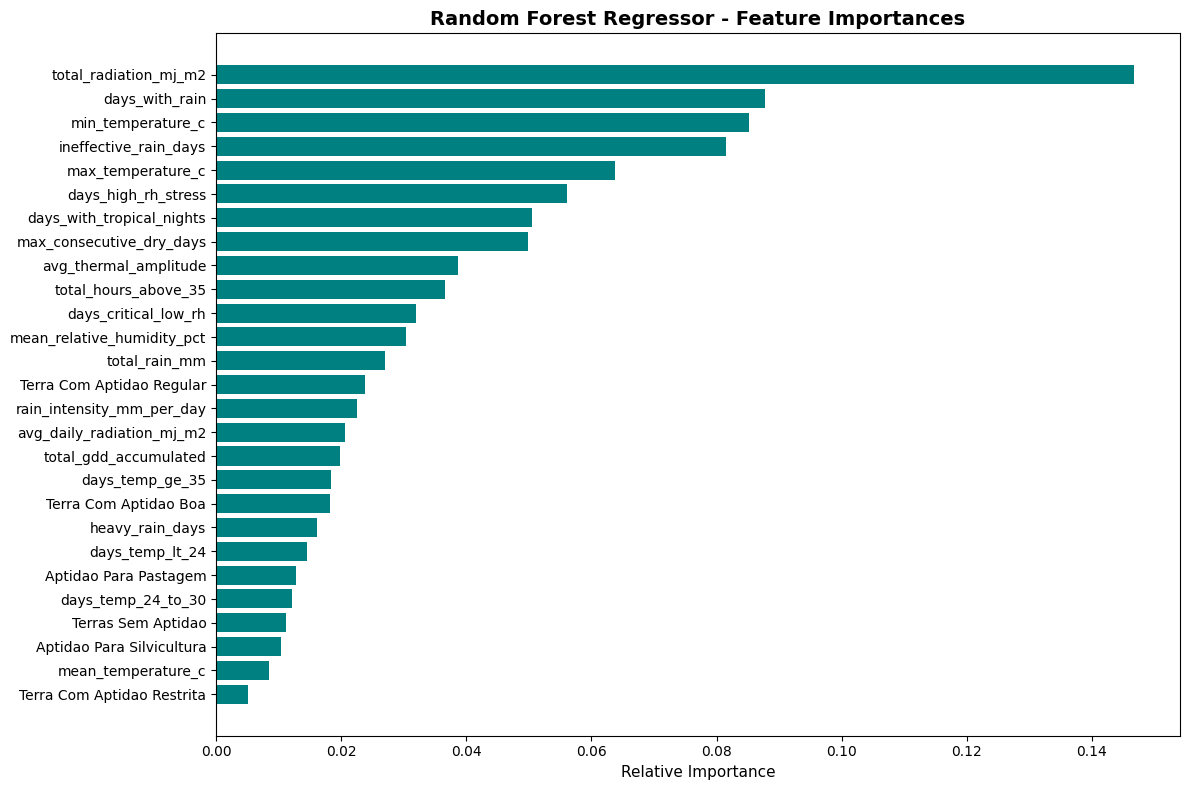

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


importances = modelo_rf.feature_importances_

indices = np.argsort(importances)[::-1]

sorted_features = [features[i] for i in indices]
sorted_importances = importances[indices]

importance_df = pd.DataFrame({
    'Feature': sorted_features,
    'Importance_Score': sorted_importances
})


plt.figure(figsize=(12, 8))
plt.title("Random Forest Regressor - Feature Importances", fontsize=14, fontweight='bold')

plt.barh(range(len(features)), sorted_importances[::-1], align="center", color="teal")
plt.yticks(range(len(features)), sorted_features[::-1], fontsize=10)
plt.xlabel("Relative Importance", fontsize=11)

plt.tight_layout()
plt.savefig('rf_importance.pdf')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = df_final.copy()

target = 'yield_kg_ha'
features = [col for col in df.columns if col not in [target, 'year', 'planted_area_ha']]

dados_treino = df[(df['year'] >= 2003) & (df['year'] <= 2020)]
X_train = dados_treino[features]
y_train = dados_treino[target]

dados_teste = df[(df['year'] >= 2021) & (df['year'] <= 2024)]
X_test = dados_teste[features]
y_test = dados_teste[target]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

modelo_xgb.fit(X_train_scaled, y_train)

predicoes = modelo_xgb.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predicoes)
rmse = np.sqrt(mean_squared_error(y_test, predicoes))
r2 = r2_score(y_test, predicoes)

print(f"MAE: {mae:.2f} kg/ha")
print(f"RMSE: {rmse:.2f} kg/ha")
print(f"R²: {r2:.4f}")

=== Resultados do XGBoost (Teste: 2021-2024) ===
MAE: 1062.64 kg/ha
RMSE: 1252.04 kg/ha
R²: -1.8713


=== XGBoost: Top 10 Features (By Gain) ===
                     Feature  Importance_Gain
0  avg_daily_radiation_mj_m2         0.167309
1      total_radiation_mj_m2         0.094758
2             days_with_rain         0.060288
3   max_consecutive_dry_days         0.050153
4      ineffective_rain_days         0.049803
5        days_high_rh_stress         0.049697
6       total_hours_above_35         0.045557
7      avg_thermal_amplitude         0.042160
8          min_temperature_c         0.040141
9       days_critical_low_rh         0.035873


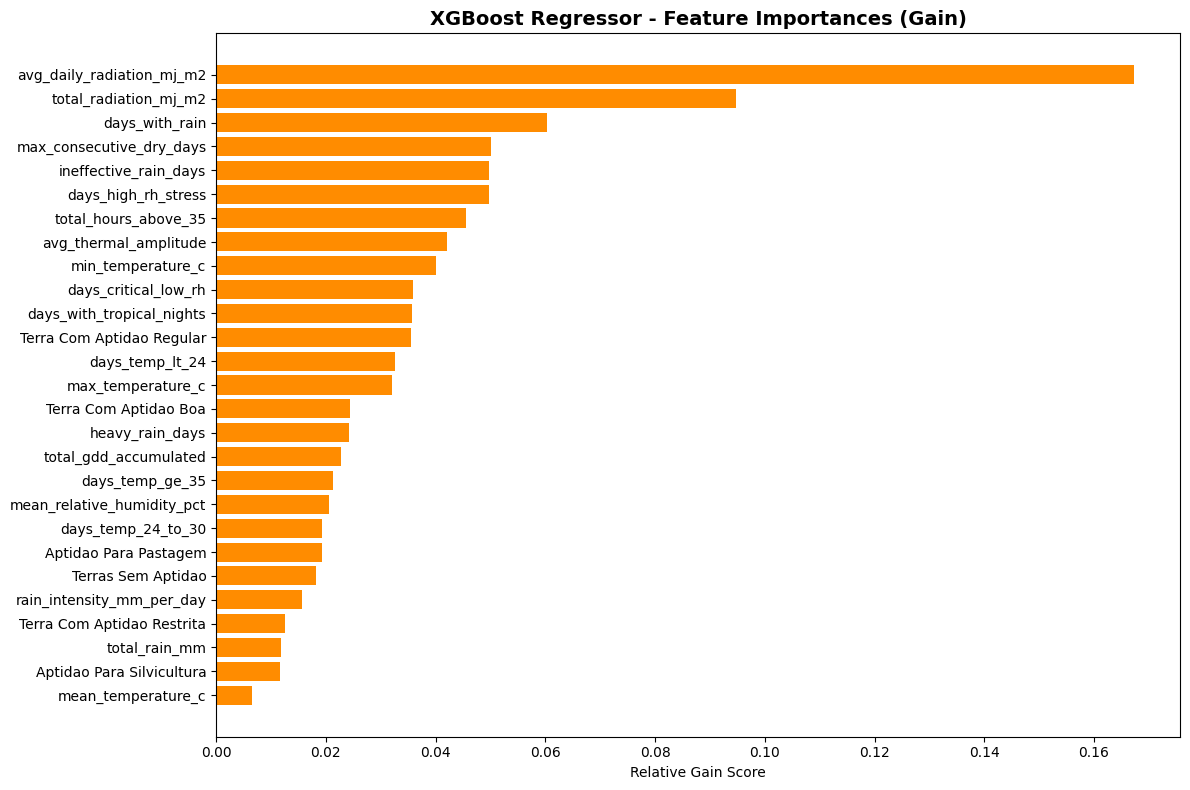

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

xgb_importances = modelo_xgb.feature_importances_
indices = np.argsort(xgb_importances)[::-1]

xgb_importance_df = pd.DataFrame({
    'Feature': [features[i] for i in indices],
    'Importance_Gain': xgb_importances[indices]
})

plt.figure(figsize=(12, 8))
plt.title("XGBoost Regressor - Feature Importances (Gain)", fontsize=14, fontweight='bold')
plt.barh(range(len(features)), xgb_importances[indices][::-1], align="center", color="darkorange")
plt.yticks(range(len(features)), [features[i] for i in indices][::-1])
plt.xlabel("Relative Gain Score")
plt.tight_layout()
plt.savefig('xgb_importance.pdf')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [5, 10, 20, 40],
    'min_samples_leaf': [2, 5, 10, 20],
    'criterion': ['squared_error', 'absolute_error'] 
}

base_tree = DecisionTreeRegressor(random_state=42)

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    cv=tscv,
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

print("Optimizing Decision Tree... This might take a few seconds.")
grid_search.fit(X_train_scaled, y_train)

best_params = grid_search.best_params_
best_tree = grid_search.best_estimator_

optimized_predictions = best_tree.predict(X_test_scaled)

print("\n=== Best Hyperparameters Found ===")
for param, value in best_params.items():
    print(f"{param}: {value}")

print("\n=== Optimized Decision Tree Results (2021-2024) ===")
print(f"MAE: {mean_absolute_error(y_test, optimized_predictions):.2f} kg/ha")
print(f"R² Score: {r2_score(y_test, optimized_predictions):.4f}")

Optimizing Decision Tree... This might take a few seconds.
Fitting 5 folds for each of 192 candidates, totalling 960 fits


c:\Users\franc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



=== Best Hyperparameters Found ===
criterion: absolute_error
max_depth: 6
min_samples_leaf: 5
min_samples_split: 40

=== Optimized Decision Tree Results (2021-2024) ===
MAE: 1165.85 kg/ha
R² Score: -2.7440
